# Experiment 4.2: Logistic Regression Hyperparameter Tuning & Imbalance Handling
In this notebook, we explore **Logistic Regression** and systematically test various imbalance handling techniques using **Optuna**.

### Why Logistic Regression?
Logistic Regression is a foundational classification algorithm known for its simplicity and effectiveness.
- **Interpretability**: It provides clear coefficients that indicate the importance and direction of each feature's influence on the prediction.
- **High-Dimensional Efficiency**: It performs exceptionally well on high-dimensional sparse data, making it a classic choice for TF-IDF based text classification.
- **Probabilistic Output**: Unlike some black-box models, Logistic Regression provides well-calibrated probabilities for class membership.
- **Fast Training**: It is computationally efficient, allowing for rapid experimentation.

### Imbalance Handling Strategy
We will evaluate the same four oversampling techniques:
1. **SMOTE**
2. **SMOTETomek**
3. **Borderline-SMOTE**
4. **ADASYN**

### Setup:
- **Features**: TF-IDF (2500 features) + 3 Custom numeric features.
- **Scaling**: `RobustScalar`.
- **Optimization**: Optuna search for `C` (regularization strength), `penalty` (L1/L2), and the best imbalance strategy.

In [1]:
import pandas as pd
import numpy as np
import mlflow
import os
import tempfile
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (accuracy_score, f1_score, precision_score, 
                              recall_score, classification_report, confusion_matrix)
from sklearn.linear_model import LogisticRegression
from scipy.sparse import hstack
from imblearn.over_sampling import SMOTE, ADASYN, BorderlineSMOTE
from imblearn.combine import SMOTETomek
from imblearn.pipeline import Pipeline

c:\data-science-projects\major-projects\youtube_comment_analysis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Set MLflow tracking
mlflow.set_tracking_uri("http://localhost:5000")
mlflow.set_experiment("Logistic Regression Hyperparameter Tuning-2")

2026/04/14 14:52:10 INFO mlflow.tracking.fluent: Experiment with name 'Logistic Regression Hyperparameter Tuning-2' does not exist. Creating a new experiment.


<Experiment: artifact_location='mlflow-artifacts:/19', creation_time=1776158530129, experiment_id='19', last_update_time=1776158530129, lifecycle_stage='active', name='Logistic Regression Hyperparameter Tuning-2', tags={}, workspace='default'>

In [4]:
# Load and preprocess
data = pd.read_csv(r'../data/processed/dataset.csv')
data = data.dropna(subset=['text_processed', 'sentiment']).drop_duplicates()

# Keep raw features for Pipeline processing
X = data[['text_processed', 'char_count', 'word_count', 'avg_word_len']]
y = data['sentiment']

le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# ── Industrial Best Practice: Preprocessing Pipeline ────────────────────────
preprocessor = ColumnTransformer([
    ('tfidf', TfidfVectorizer(max_features=2500, ngram_range=(1,1)), 'text_processed'),
    ('scaler', RobustScaler(), ['char_count', 'word_count', 'avg_word_len'])
])

In [5]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    # Logistic Regression Hyperparameters
    penalty = trial.suggest_categorical('penalty', ['l1', 'l2', 'elasticnet'])
    C = trial.suggest_float('C', 0.001, 100, log=True)
    l1_ratio = trial.suggest_float('l1_ratio', 0, 1) if penalty == 'elasticnet' else None
    
    lr_params = {
        'penalty': penalty,
        'C': C,
        'l1_ratio': l1_ratio,
        'solver': 'saga',
        'max_iter': 2000, 
        'random_state': 42,
        'n_jobs': -1
    }

    # Imbalance Strategy Choice
    resampler_name = trial.suggest_categorical('resampler', ['none', 'smote', 'smotetomek', 'borderline', 'adasyn'])
    
    if resampler_name == 'none':
        resampler = None
    elif resampler_name == 'smote':
        resampler = SMOTE(random_state=42)
    elif resampler_name == 'smotetomek':
        resampler = SMOTETomek(random_state=42)
    elif resampler_name == 'borderline':
        resampler = BorderlineSMOTE(random_state=42)
    elif resampler_name == 'adasyn':
        resampler = ADASYN(random_state=42)

    # ── Full Leak-Proof Pipeline ─────────────────────────────────────────────
    steps = [('preprocessor', preprocessor)]
    if resampler:
        steps.append(('resampler', resampler))
    steps.append(('classifier', LogisticRegression(**lr_params)))
    
    model_pipeline = Pipeline(steps)

    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    
    # ── Industrial Bottleneck Objective ──────────────────────────────────────
    def bottleneck_objective_scorer(estimator, X, y):
        y_pred = estimator.predict(X)
        neutral_label_idx = np.where(le.classes_ == 0)[0][0]
        precisions = precision_score(y, y_pred, average=None, labels=[0, 1, 2], zero_division=0)
        prec_neutral = precisions[neutral_label_idx]
        f1_macro = f1_score(y, y_pred, average='macro')
        return (0.70 * prec_neutral) + (0.30 * f1_macro)

    with mlflow.start_run(nested=True, run_name=f"Trial_{trial.number}"):
        cv_scores = cross_val_score(
            model_pipeline, X_train, y_train, 
            cv=skf, scoring=bottleneck_objective_scorer
        )
        avg_combined_score = float(np.mean(cv_scores))

        mlflow.log_params(lr_params)
        mlflow.log_param("resampler", resampler_name)
        mlflow.log_metrics({
            "cv_avg_bottleneck_score": avg_combined_score,
            "cv_std_dev": float(np.std(cv_scores)),
            "trial_number": trial.number,
        })

    return avg_combined_score

with mlflow.start_run(run_name="Optuna_LogisticRegression_CV_Search"):
    study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(objective, n_trials=25)

    mlflow.log_params(study.best_params)
    mlflow.log_metric("best_cv_bottleneck_score", study.best_value)

    print(f"Best CV Score: {study.best_value:.4f}")
    print(f"Best Params: {study.best_params}")

c:\data-science-projects\major-projects\youtube_comment_analysis\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\data-science-projects\major-projects\youtube_comment_analysis\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l2 with l1_ratio=None. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\data-science-projects\major-projects\youtube_comment_analysis\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=Future

🏃 View run Trial_0 at: http://localhost:5000/#/experiments/19/runs/605c3c477d244a20843ae93456b6caa1
🧪 View experiment at: http://localhost:5000/#/experiments/19


c:\data-science-projects\major-projects\youtube_comment_analysis\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\data-science-projects\major-projects\youtube_comment_analysis\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
c:\data-science-projects\major-projects\youtube_comment_analysis\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty'

🏃 View run Trial_1 at: http://localhost:5000/#/experiments/19/runs/6e7eaaf33db541aaac0684674a60cabd
🧪 View experiment at: http://localhost:5000/#/experiments/19


c:\data-science-projects\major-projects\youtube_comment_analysis\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\data-science-projects\major-projects\youtube_comment_analysis\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l2 with l1_ratio=None. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\data-science-projects\major-projects\youtube_comment_analysis\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=Future

...

🏃 View run Trial_22 at: http://localhost:5000/#/experiments/19/runs/72a98d84bb614fe1b88c97b218c54eed
🧪 View experiment at: http://localhost:5000/#/experiments/19


c:\data-science-projects\major-projects\youtube_comment_analysis\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\data-science-projects\major-projects\youtube_comment_analysis\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
c:\data-science-projects\major-projects\youtube_comment_analysis\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\data-science-projects\ma

🏃 View run Trial_23 at: http://localhost:5000/#/experiments/19/runs/dc62eccea7d24cce804042a10a3cacf9
🧪 View experiment at: http://localhost:5000/#/experiments/19


c:\data-science-projects\major-projects\youtube_comment_analysis\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\data-science-projects\major-projects\youtube_comment_analysis\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
c:\data-science-projects\major-projects\youtube_comment_analysis\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty'

🏃 View run Trial_24 at: http://localhost:5000/#/experiments/19/runs/456ea00ddbac4550aeea209ef23cdf03
🧪 View experiment at: http://localhost:5000/#/experiments/19
Best CV Score: 0.8287
Best Params: {'penalty': 'elasticnet', 'C': 4.714056812332276, 'l1_ratio': 0.03632074934926926, 'resampler': 'none'}
🏃 View run Optuna_LogisticRegression_CV_Search at: http://localhost:5000/#/experiments/19/runs/964ee9c976c748ec8e7c0e7deb24e68a
🧪 View experiment at: http://localhost:5000/#/experiments/19


c:\data-science-projects\major-projects\youtube_comment_analysis\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\data-science-projects\major-projects\youtube_comment_analysis\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


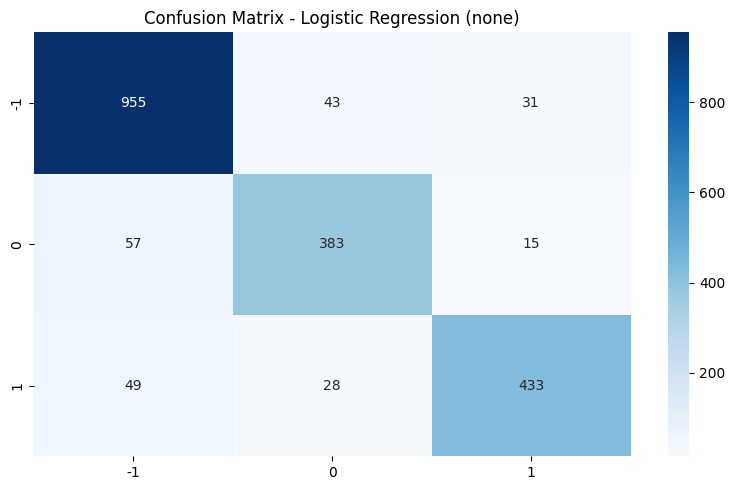

🏃 View run LogisticRegression_Optimized_Final at: http://localhost:5000/#/experiments/19/runs/ce51bb0e452746ab825f9035d514e05c
🧪 View experiment at: http://localhost:5000/#/experiments/19


In [6]:
best_params = study.best_params.copy()
resampler_name = best_params.pop('resampler')

lr_final_params = {
    'solver': 'saga',
    'max_iter': 2000,
    'random_state': 42,
    'n_jobs': -1
}
lr_final_params.update(best_params)

# Re-create the best resampler
if resampler_name == 'none':
    resampler = None
elif resampler_name == 'smote':
    resampler = SMOTE(random_state=42)
elif resampler_name == 'smotetomek':
    resampler = SMOTETomek(random_state=42)
elif resampler_name == 'borderline':
    resampler = BorderlineSMOTE(random_state=42)
elif resampler_name == 'adasyn':
    resampler = ADASYN(random_state=42)

with mlflow.start_run(run_name="LogisticRegression_Optimized_Final"):
    # Re-build final pipeline
    steps = [('preprocessor', preprocessor)]
    if resampler:
        steps.append(('resampler', resampler))
    steps.append(('classifier', LogisticRegression(**lr_final_params)))
    
    final_pipeline = Pipeline(steps)
    final_pipeline.fit(X_train, y_train)
    y_pred = final_pipeline.predict(X_test)
    
    # ── Log Parameters ────────────────────────────────────────────────────────
    full_params = {
        "test_size": 0.2,
        "stratify": True,
        "representation": "TFIDF_2500",
        "scaler": "RobustScaler",
        "model_name": "LogisticRegression_Optimized",
        "resampler": resampler_name,
        "leak_proof": True
    }
    full_params.update(lr_final_params)
    mlflow.log_params(full_params)

    # ── Log Metrics ───────────────────────────────────────────────────────────
    report_dict = classification_report(y_test, y_pred, output_dict=True)
    metrics = {
        "accuracy": accuracy_score(y_test, y_pred),
        "f1_weighted": report_dict['weighted avg']['f1-score'],
        "f1_macro": report_dict['macro avg']['f1-score'],
        "precision_macro": report_dict['macro avg']['precision'],
        "recall_macro": report_dict['macro avg']['recall']
    }
    for i, label in enumerate(le.classes_):
        metrics[f"f1_class_{label}"] = report_dict[str(i)]['f1-score']
        metrics[f"precision_class_{label}"] = report_dict[str(i)]['precision']
        metrics[f"recall_class_{label}"] = report_dict[str(i)]['recall']
    mlflow.log_metrics(metrics)

    # ── Log Artifacts ─────────────────────────────────────────────────────────
    report_str = classification_report(y_test, y_pred, target_names=le.classes_.astype(str))
    with tempfile.TemporaryDirectory() as tmp_dir:
        report_path = os.path.join(tmp_dir, "classification_report.txt")
        with open(report_path, "w") as f:
            f.write(report_str)
        mlflow.log_artifact(report_path)

        plt.figure(figsize=(8, 5))
        sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
                    xticklabels=le.classes_, yticklabels=le.classes_)
        plt.title(f'Confusion Matrix - Logistic Regression ({resampler_name})')
        plt.tight_layout()
        cm_path = os.path.join(tmp_dir, "confusion_matrix.png")
        plt.savefig(cm_path)
        mlflow.log_artifact(cm_path)
        plt.show()
        plt.close()

#### Conclusion: 
we are using lightGBM model since lightgbm is giving better results than logistic regression.

model parms -> best
config = {
    "test_size": 0.2,
    "stratify": True,
    "representation": "TFIDF_2500",
    "scaler": "RobustScaler",
    "model_name": "LightGBM_Optimized",
    "resampler": "none",
    "leak_proof": True,
    "n_estimators": 1240,
    "learning_rate": 0.03323249830949845,
    "num_leaves": 147,
    "max_depth": 13,
    "min_child_samples": 5,
    "subsample": 0.9369645117719385,
    "colsample_bytree": 0.6612183865216443,
    "reg_alpha": 1.3237755854340723e-08,
    "reg_lambda": 3.861791897485102e-08,
    "min_split_gain": 0.6329924721339453,
    "random_state": 42,
    "verbosity": -1
}